# Skeletal muscle: base clustering (supporting)

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}npc.tsv'`  ·  _metadata_
- `f'{indir}L2/{ct}/5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L2/{ct}/100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L2/{ct}/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{outdir}{ct}_mergeany_rocpr.npy'`  ·  _other_
- `f'{ENTEX_ROOT}/allclist.tsv'`  ·  _sc/pseudobulk mC (allc)_
- `'Mus-Skl/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [3]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [4]:
indir = f'{ENTEX_ROOT}/clustering/merged/'
outdir = f'{ENTEX_ROOT}/analysis/pairwise_prediction/'


In [5]:
ct = 'Mus-Skl'


In [6]:
npc = pd.read_csv(f'{indir}npc.tsv', sep='\t', header=None, index_col=0, names=['npc_cg', 'npc_3c'])

In [7]:
adata_mc = anndata.read_h5ad(f'{indir}L2/{ct}/5kCG_embed.h5ad')
adata_3c = anndata.read_h5ad(f'{indir}L2/{ct}/100k3C_embed.h5ad')
adata_3c = adata_3c[adata_mc.obs.index].copy()


In [8]:
coord_base = 'tsne'
adata = anndata.read_h5ad(f'{indir}L2/{ct}/5kCG100k3C_embed.h5ad')
npc_cg, npc_3c = npc.loc[ct].values
labelany = np.load(f'{outdir}{ct}_mergeany_rocpr.npy', allow_pickle=True)
# labelboth = np.load(f'{outdir}{ct}_mergeboth_rocpr.npy', allow_pickle=True)
ds = 150/np.sqrt(adata.shape[0])


In [9]:
# clustering name
clustering_name = 'L1'

# ConsensusClustering
# Important factores
n_neighbors = 25
leiden_resolution = 0.5
# this parameter is the final target that limit the total number of clusters
# Higher accuracy means more conservative clustering results and less number of clusters
target_accuracy = 0.85
min_cluster_size = 50

# Other ConsensusClustering parameters
metric = 'euclidean'
consensus_rate = 0.8
leiden_repeats = 500
random_state = 0
train_frac = 0.5
train_max_n = 500
max_iter = 50
n_jobs = 32

# Dendrogram via Multiscale Bootstrap Resampling
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'

plot_type = 'static'

In [10]:
cc = ConsensusClustering(model=None,
                         n_neighbors=n_neighbors,
                         metric=metric,
                         min_cluster_size=min_cluster_size,
                         leiden_repeats=leiden_repeats,
                         leiden_resolution=leiden_resolution,
                         consensus_rate=consensus_rate,
                         random_state=random_state,
                         train_frac=train_frac,
                         train_max_n=train_max_n,
                         max_iter=max_iter,
                         n_jobs=n_jobs,
                         target_accuracy=target_accuracy)


In [11]:
cc.fit_predict(normalize(adata_3c.obsm[f'100k3C_pc{npc_3c}_seuratL2'], axis=1))
adata_3c.obs[f'100k3C_pc{npc_3c}_leiden_init'] = cc.label.copy()


In [12]:
cc.fit_predict(normalize(adata_mc.obsm[f'5kCG_u{npc_cg}_seuratL2'], axis=1))
adata_mc.obs[f'5kCG_u{npc_cg}_leiden_init'] = cc.label.copy()


In [13]:
fig, axes = plt.subplots(3, 3, figsize=(12,9), dpi=300)
for i,xx in enumerate([adata, adata_mc, adata_3c]):
    tmp = xx.obs.copy()
    for j,yy in enumerate([adata.obs['leiden_init'], 
                           adata_mc.obs[f'5kCG_u{npc_cg}_leiden_init'], 
                           adata_3c.obs[f'100k3C_pc{npc_3c}_leiden_init']]):
        
        ax = axes[i,j]
        _ = categorical_scatter(data=tmp,
                                ax=ax,
                                coord_base=coord_base,
                                hue=yy,
                                text_anno=yy, 
                                s=ds,
                                labelsize=12,
                                max_points=None,
                                palette='tab20',
                                scatter_kws={'rasterized':True},
                                # legend_kws={'ncol':1}, 
                                # show_legend=True
                               )


In [14]:
adata.obs['leiden_init_mc'] = adata_mc.obs[f'5kCG_u{npc_cg}_leiden_init'].copy()
adata.obs['leiden_init_3c'] = adata_3c.obs[f'100k3C_pc{npc_3c}_leiden_init'].copy()
# leiden_group_mc = [[0], [3,5,8,10,11,13,15,17,19], [1,2,4,6,7,9,14,18]]
# leiden_group_mc = [[2], [0,5,8,9],[1,3,4,6,7]]
leiden_group_mc = [[0],[3,5,8,10,11,13,15,16],[1,2,4,6,7,9,12,14]]
leiden_group_3c = [[8], [1,4,5,6,7,9], [0,2,3]]
leiden_map = {f'c{xx}':f'mc{i}' for i,x in enumerate(leiden_group_mc) for xx in x}
adata_mc.obs['leiden_group'] = adata.obs['leiden_init_mc'].map(leiden_map)
leiden_map = {f'c{xx}':f'3c{i}' for i,x in enumerate(leiden_group_3c) for xx in x}
adata_3c.obs['leiden_group'] = adata.obs['leiden_init_3c'].map(leiden_map)
adata.obs['leiden_group_mc'] = adata_mc.obs['leiden_group'].copy()
adata.obs['leiden_group_3c'] = adata_3c.obs['leiden_group'].copy()
adata.obs[['leiden_group_mc', 'leiden_group_3c']].value_counts().unstack()


In [15]:
adata.obs['group_mc_3c'] = adata.obs['leiden_group_mc'].astype(str) + '-' + adata.obs['leiden_group_3c'].astype(str)


In [16]:
adata.write_h5ad('Mus-Skl/5kCG100k3C_embed.h5ad')
adata_mc.write_h5ad('Mus-Skl/5kCG_embed.h5ad')
adata_3c.write_h5ad('Mus-Skl/100k3C_embed.h5ad')


In [17]:
adata.obs['allcpath'] = '/gale/netapp/entex/ENTEx/allc_CGN/' + adata.obs.index + '.CGN-Both.allc.tsv.gz'
# adata.obs['allcpath'] = allc_table.loc[adata.obs.index, 1]
adata.obs['coolpath'] = 'gs://ecker-zhoujt-analysis/ENTEx/tissue/' + adata.obs['Tissue'].astype(str) + '/impute/10K/' + adata.obs.index + '.cool'


In [18]:
tmp = adata.obs[['leiden_group_mc', 'leiden_group_3c', 'allcpath', 'coolpath']].copy()
tmp['group_mc_3c'] = tmp['leiden_group_mc'].astype(str) + '-' + tmp['leiden_group_3c'].astype(str)
count = tmp['group_mc_3c'].value_counts()
tmp = tmp.loc[tmp['group_mc_3c'].isin(count.index[count>100])]
tmp[['allcpath', 'group_mc_3c']].to_csv('Mus-Skl/allclist_mc3cgroup.csv', index=False, header=False)
tmp[['coolpath', 'group_mc_3c']].to_csv('Mus-Skl/coollist_mc3cgroup.csv', index=True, header=False)


In [19]:
tmp['leiden_init_mc'] = adata_mc.obs[f'5kCG_u{npc_cg}_leiden_init'].copy()
tmp[['allcpath', 'leiden_init_mc']].to_csv('Mus-Skl/allclist_mc.csv', index=False, header=False)


In [20]:
adata = anndata.read_h5ad('Mus-Skl/5kCG100k3C_embed.h5ad')


In [21]:
# def rename_cluster(xx):
#     yy = xx.replace('-',' ').replace('c', 'C')
#     yy = yy.replace('0', '-Stem').replace('1', '-Fast').replace('2', '-Slow')
#     return yy
def rename_cluster(xx):
    yy = xx.replace('-','/').replace('mc','').replace('3c','')
    yy = yy.replace('0', 'Stem').replace('1', 'Fast').replace('2', 'Slow')
    return yy


In [22]:
leg = np.sort(adata.obs['group_mc_3c'].unique())
k1, k2 = 0, 0
color_palette = {}
for xx in leg:
    x1, x2 = xx.split('-')
    if x1[1:]==x2[1:]:
        color_palette[rename_cluster(xx)] = sns.color_palette('tab20')[k1*2+1]
        k1 += 1
    else:
        color_palette[rename_cluster(xx)] = sns.color_palette('tab20')[k2*2]
        k2 += 1


In [23]:
adata.obs['celltype'] = meta.loc[adata.obs.index, 'celltype_abbr'].astype(str)
adata.obs[['celltype', 'leiden_group_mc']].value_counts().unstack().fillna(0)

In [24]:
count = adata.obs[['leiden_group_mc', 'leiden_group_3c']].value_counts().unstack()
count

In [25]:
fig, ax = plt.subplots(figsize=(4,4))
ax.table(cellText=count.values, 
         cellLoc='center', 
         loc='center', 
         rowLoc='right',
         rowLabels=count.index.map(rename_cluster), 
         colLabels=count.columns.map(rename_cluster))
ax.axis('off')

fig.tight_layout()
fig.savefig(f'{ct}/confusion_table.pdf', transparent=True)


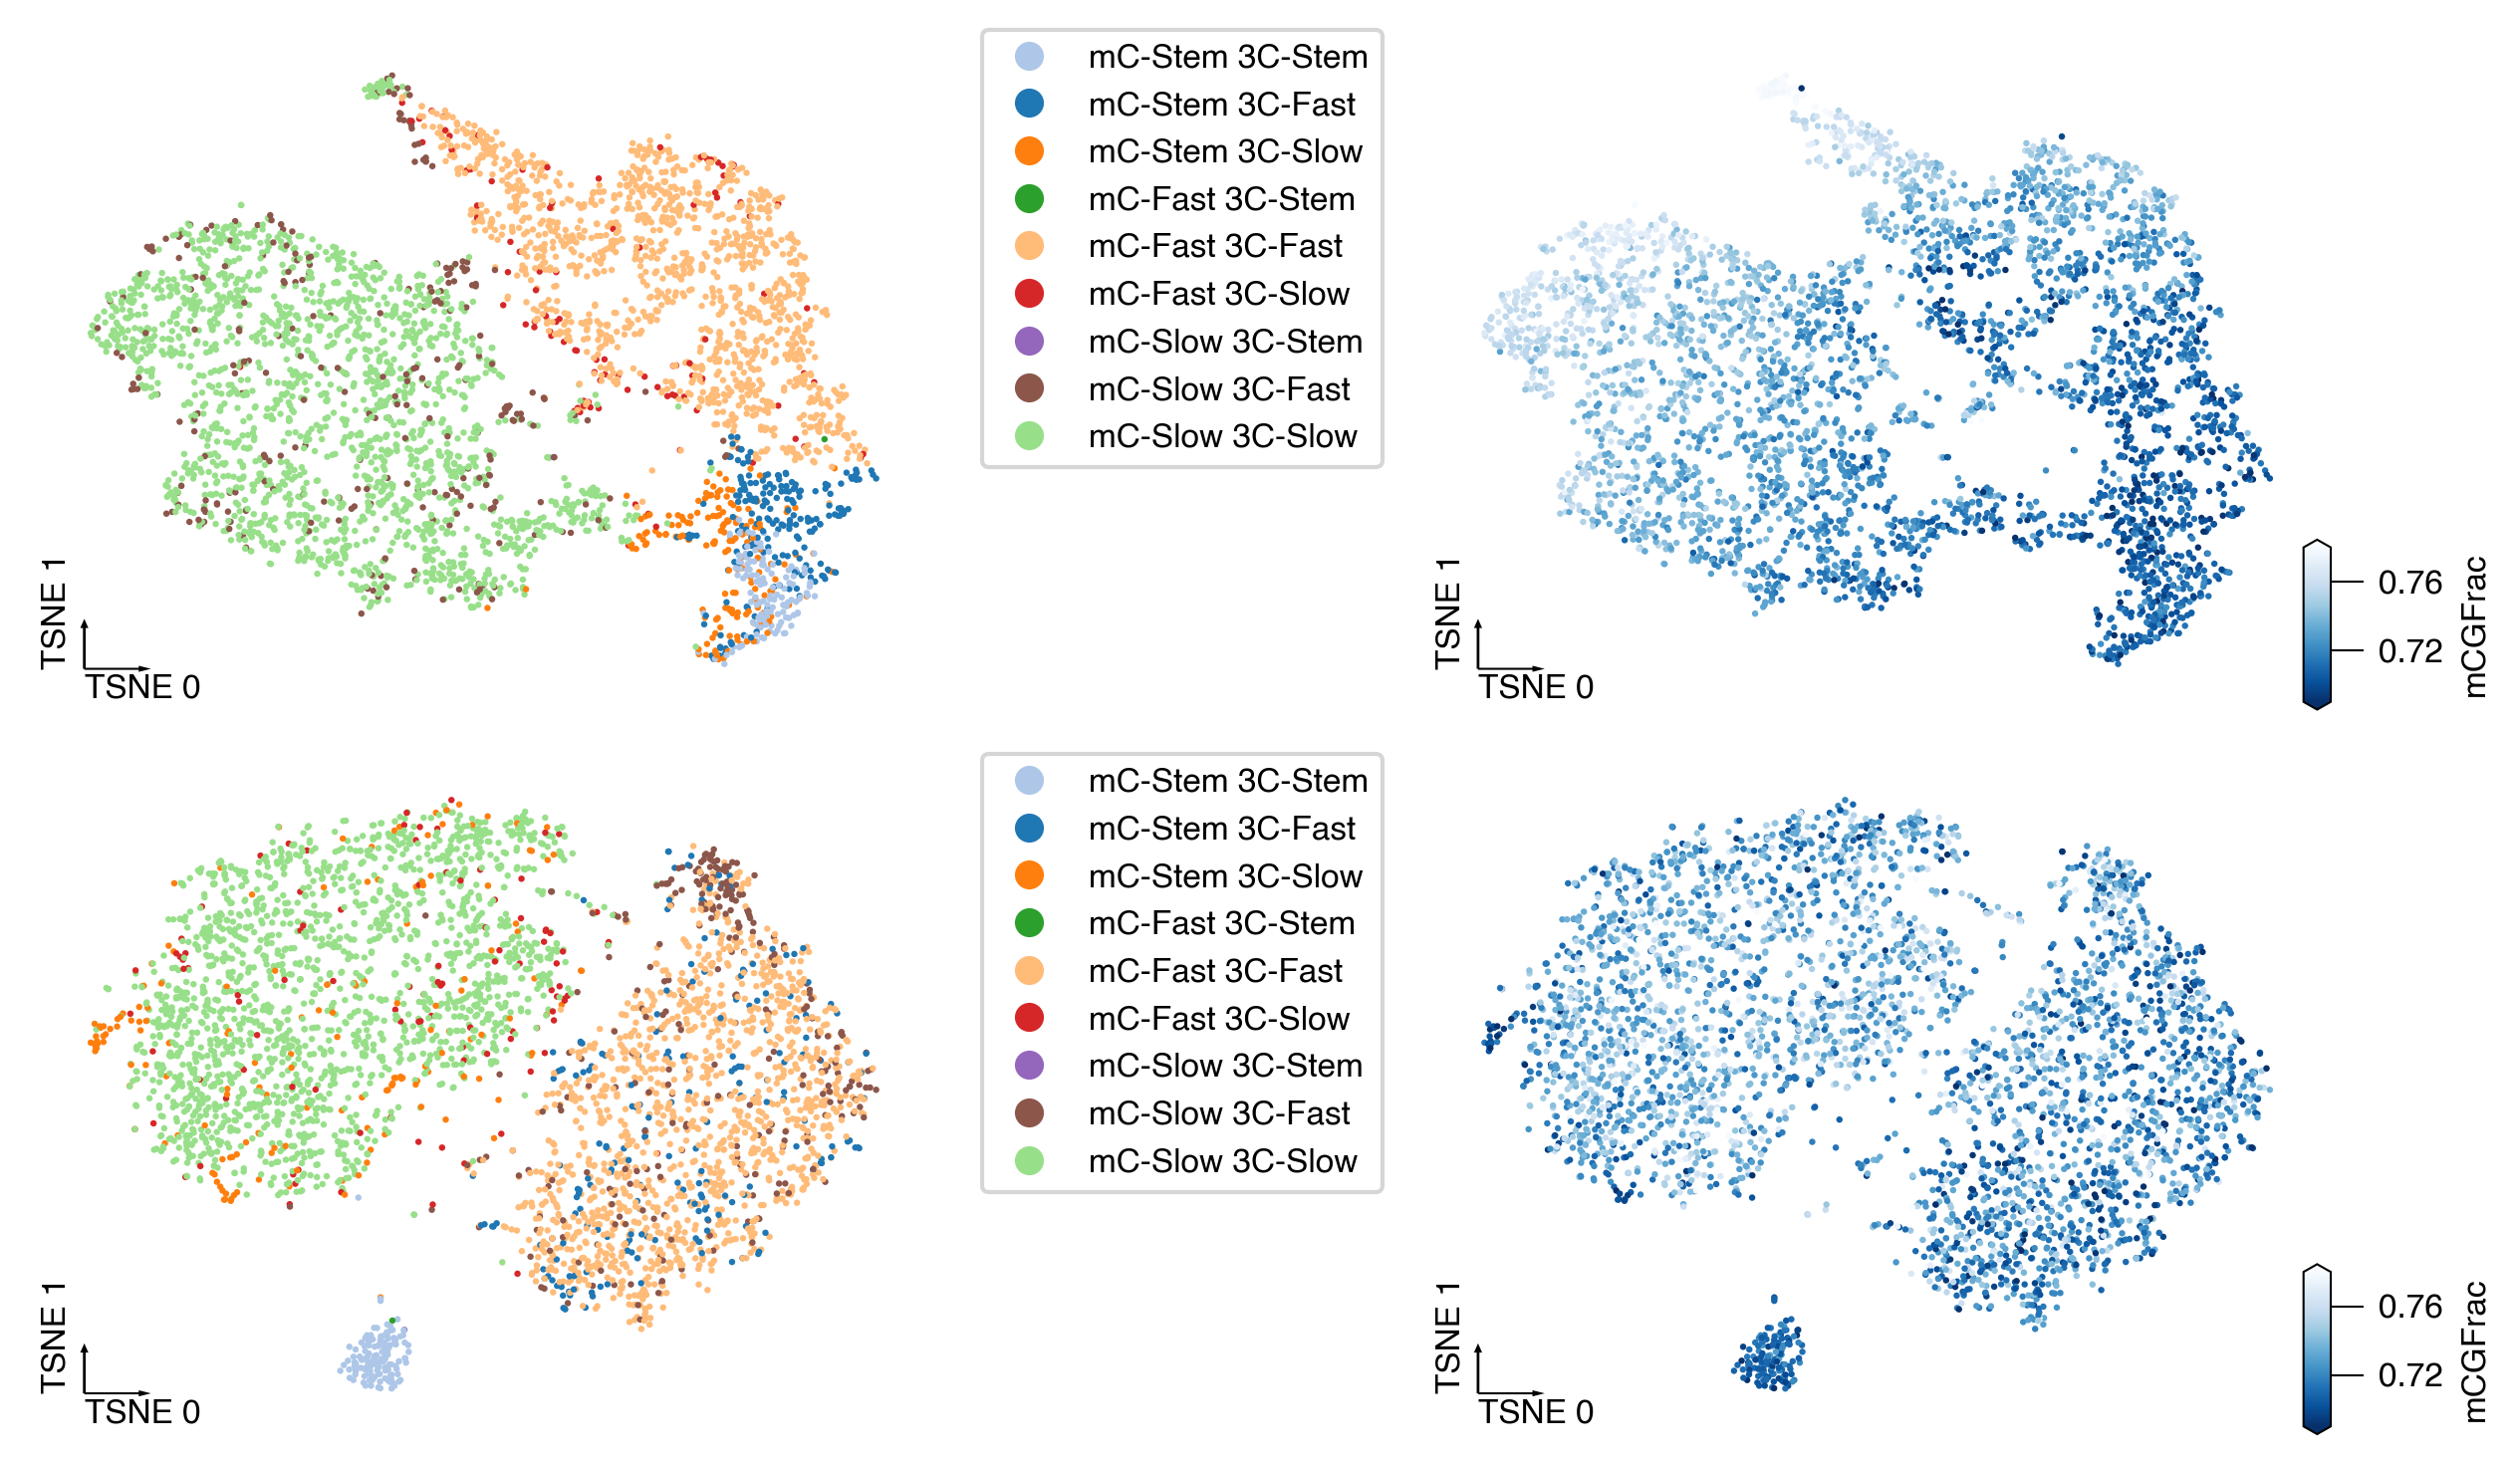

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(8,5), dpi=300)
for i,adata_tmp in enumerate([adata_mc, adata_3c]):
    tmp = adata_tmp.obs.copy()
    tmp['group_mc_3c'] = adata.obs['group_mc_3c'].astype(str)
    tmp['group_mc_3c'] = tmp['group_mc_3c'].map(rename_cluster)
    ax = axes[i,0]
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue='group_mc_3c',
                            # text_anno='group_mc_3c', 
                            s=ds,
                            labelsize=8,
                            max_points=None,
                            palette=color_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            show_legend=True
                            )
    ax = axes[i,1]
    _ = continuous_scatter(data=tmp,
                           ax=ax,
                           coord_base=coord_base,
                           hue=adata.obs['mCGFrac'],
                           s=ds,
                           cmap='Blues_r',
                           labelsize=8,
                           max_points=None,
                           scatter_kws={'rasterized':True},
                           hue_norm=[0.69, 0.78],
                           )

fig.tight_layout()
fig.savefig('Mus-Skl/mC_3C_embed_group_mCG.pdf', transparent=True)
